In [1]:
import numpy as np
import matplotlib.pyplot as plt

![robotarm](C:/Users/henri/OneDrive%20-%20Aarhus%20universitet/2.%20Semester/Numerisk%20Lineær%20Algebra/TØ/Opgavesæt%202/Billeder/robotarm.png)

$$
% uncomment det her hvis man vil se billedet rendered
% ![robotarm](Billeder/robotarm.png)
$$

En robotarm består af 4 stænger $OA$, $AB$, $BC$ og $CP$ samlet i planen således at armen kan bøjes ved ledderne $O$, $A$, $B$ og $C$. Lad $a = \overrightarrow{OA}$, $b = \overrightarrow{AB}$, $c = \overrightarrow{BC}$ og $d = \overrightarrow{CP}$. Robotarmens stilling er bestemt af matricen
$$
S = [a | b | c | d]
$$

## (a) {-}

Vælg nogle passende værdier for indgangene i **a**, **b**, **c** og **d**, og brug derefter *matplotlib* til at lave en tegningen af robotarmen, som minder om den ovenfor.

$\ $

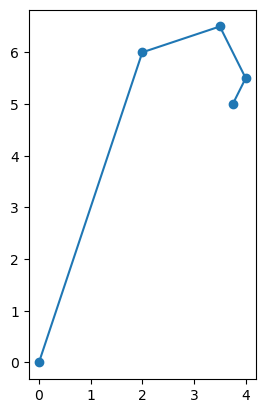

In [2]:
# Definerer punkterne
O = np.array([0, 0])
A = np.array([2, 6])
B = np.array([3.5, 6.5])
C = np.array([4, 5.5])
P = np.array([3.75, 5])

# Definerer vektorerne som stedvektorer (beholdes i punktformat pga plot)
a = A - O
b = B - A
c = C - B
d = P - C

# Siden de er stedvektorer skal de lægges sammen for ikke at ligge i origo
S = np.array([O,    # første punkt skal være origo pga a (vektor OA)
              a, 
              a + b, 
              a + b + c, 
              a + b + c + d])

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(S[:, 0], S[:, 1], marker='o')

## (b) {-}

Bestem vektoren $\overrightarrow{OP}$ ud fra **a**, **b**, **c**, **d**.

$\ $

In [3]:
# vektoren findes som summen af de andre vektorer da de alle er forbundet
OP = a + b + c + d

# her sættes vektoren på normal vektor form for pænere output
OP[:, np.newaxis]

array([[3.75],
       [5.  ]])

$\pagebreak$

## (c) {-}

Gør rede for at når armen bøjes i ledet 𝐶, svarer det til at anvende en
rotationsmatrix 𝑅𝐶 på **d**, dvs.

$$
\text{bøj}_{𝐶} (𝑆) =[\textbf{a} | \textbf{b} | \textbf{c} | 𝑅_{C} \textbf{d}].
$$

Lav en matplotlib tegning der viser dette.

$\ $

Når armen bøjes i et enkelt led vil alle efterfølgende arme bøje sig samlet. I dette tilfælde er der kun en arm efter ledet i C, hvilket svarer til vektor **d**. Rotationsmatricen skal da kun anvendes på **d**, da kun den arm/vektor skal bøjes. Rotationen vil da kunne implementeres således:

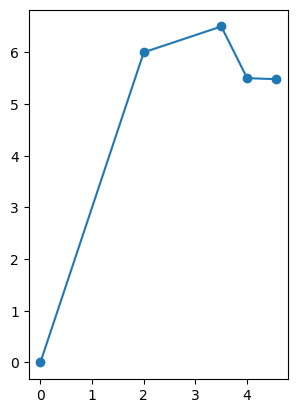

In [4]:
# Definering af rotationsmatrix
theta = 2
co = np.cos(theta)
si = np.sin(theta)

R = np.array([
    [co, -si],
    [si, co]
])

# Roterer original arm position af d
d_bend_C = R @ d

# Den nye stilling gemmes i en ny matrice med samme metode som i opg. (a)
# Da kun vektor d roteres beholdes alle de gamle værdier for de andre vektorer
S_bend_C = np.array([O, 
                    a, 
                    a + b, 
                    a + b + c, 
                    a + b + c + d_bend_C])

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(S_bend_C[:, 0], S_bend_C[:, 1], marker='o')

$\pagebreak$

## (d) {-}

Giv en opskrift for $\text{bøj}_{𝐴} (𝑆)$, hvor robotarmen bøjes kun i ledet $A$. Vis
effekten af dette i en eller flere tegninger.

$\ $

Teorien bag rotationen blev forklaret i forrige opgave. Implementeringen som pythonkoden i forrige opgave bruge ligger også til baggrund for en general funktion/opskrift. Det vides at armen kun skal roteres efter et bestemt punkt/led, hvilket betyder at en for løkke samt if-sætning er nok til at gå gennem og ændre alle vektorer, som skal ændres. Implementeringen kunne gøres som således:

In [5]:
# Generel bøjningsfunktion, som bruger følgende parametre:
# tal som repræsenterer et led/punkt bøjningen skal ske i
# (tallet svarer til positionen fra origo, hvor O=0, A=1, osv.)
# en matrix med robotarmens vektorer
# vinklen der skal roteres
def bend(point, matrix, angle):
    # Definerer rotationsmatrix
    co = np.cos(angle)
    si = np.sin(angle)
    
    R = np.array([
        [co, -si],
        [si, co]
    ])

    # Det vides at der skal være samme dimensioner efter rotationen
    new_matrix = np.empty(shape=matrix.shape, dtype='object')
    
    # Går gennem alle vektorer fra gamle matrix
    for i in range(0, matrix.shape[0]):
        # Roterer vektoren hvis den er efter rotationsleddet
        new_vec =   matrix[i] if i <= point else \
                    R @ (matrix[i] - matrix[i-1]) + new_matrix[i-1]

        # Summationen pga det er stedvektorer er indbygget i linjen over,
        # så værdierne indsættes bare i en ny matrix som de er 
        new_matrix[i] = new_vec
    
    # Den roterede matrix returneres
    return new_matrix

$\pagebreak$

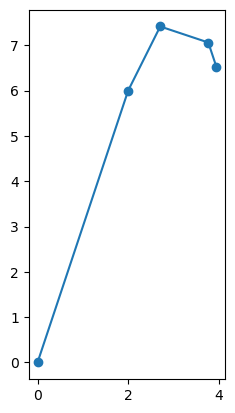

In [6]:
# bøj_A (S) med 45°
S_bend_A = bend(1, S, np.pi/4)

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(S_bend_A[:, 0], S_bend_A[:, 1], marker='o')

$\pagebreak$

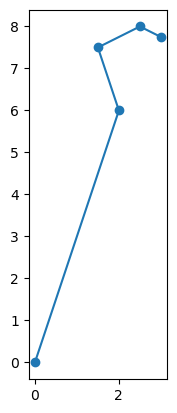

In [7]:
# bøj_A (S) med 90°
S_bend_A = bend(1, S, np.pi/2)

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(S_bend_A[:, 0], S_bend_A[:, 1], marker='o')

$\pagebreak$

## (e) {-}

Vis at

$$
\text{bøj}_{𝐴} (\text{bøj}_{𝐶} (𝑆)) = \text{bøj}_{𝐶} (\text{bøj}_{𝐴} (𝑆)),
$$

uanset hvor meget der bøjes i de givne led. Dvs. det har ingen betydning
for slutstillingen hvilket led vi bøjer først. Der må gerne bruges opskriften
fundet i delopgave (d).

$\ $


Skrives udtrykket på matrix-form vil det se ud som således:

$$
\text{bøj} (\text{bøj}_{C} ([a | b | c | d])) = \text{bøj}_{C} (\text{bøj}_{A} ([a | b | c | d]))
$$

$$
\ \ \ \ \ \ \ \ \ \ \text{bøj}_{A} ([a | b | c | R_{C}d]) = \text{bøj}_{C} ([a | R_{A}b | R_{A}c | R_{A}d])
$$

$$
[a | R_{A}b | R_{A}c | R_{A}R_{C}d] = [a | R_{A}b | R_{A}c | R_{C}R_{A}d]
$$

Her kan det ses at alle værdierne i matricerne på hver side passer med hinanden på nær de sidste. De to sidste værdier er også det samme udover at rækkefølgen af hvor rotationsmatricerne påføres er byttet om. Lighedstegnet passer da, hvis det kan vises, at rotationsmatricerne fungerer kommutativt.

$$
R_{C} R_{A} = R_{A} R_{C}
$$

$$
\begin{bmatrix}
c_{C} & -s_{C} \\
s_{C} &  c_{C}
\end{bmatrix}
\begin{bmatrix}
c_{A} & -s_{A} \\
s_{A} & c_{A}
\end{bmatrix}
=
\begin{bmatrix}
c_{A} & -s_{A} \\
s_{A} & c_{A}
\end{bmatrix}
\begin{bmatrix}
c_{C} & -s_{C} \\
s_{C} & c_{C}
\end{bmatrix}
$$

$$
\begin{bmatrix}
c_{C} c_{A} + (-s_{C}) s_{A} & c_{C} (-s_{A}) + (-s_{C}) c_{A} \\
s_{C} c_{A} + c_{C} s_{A} & s_{C} (-s_{A}) + c_{C} c_{A}
\end{bmatrix}
=
\begin{bmatrix}
c_{A} c_{C} + (-s_{A}) s_{C} &  c_{A} (-s_{C}) + (-s_{A}) c_{C} \\
s_{A} c_{C} + c_{A} s_{C} & s_{A} (-s_{C}) + c_{A} c_{C}
\end{bmatrix}
$$

$$
\begin{bmatrix}
c_{C} c_{A} - s_{C} s_{A} & - c_{C} s_{A} - s_{C} c_{A} \\
s_{C} c_{A} + c_{C} s_{A} & - s_{C} s_{A} + c_{C} c_{A}
\end{bmatrix}
=
\begin{bmatrix}
c_{A} c_{C} - s_{A} s_{C} & - c_{A} s_{C} - s_{A} c_{C} \\
s_{A} c_{C} + c_{A} s_{C} & - s_{A} s_{C} + c_{A} c_{C}
\end{bmatrix}
$$

Da både summation og multiplikation med normale scalarer/tal er kommutativt kan højresiden omskrives således at begge sider er ens:
$$
\begin{bmatrix}
c_{C} c_{A} - s_{C} s_{A} & - c_{C} s_{A} - s_{C} c_{A} \\
s_{C} c_{A} + c_{C} s_{A} & - s_{C} s_{A} + c_{C} c_{A}
\end{bmatrix}
=
\begin{bmatrix}
c_{C} c_{A} - s_{C} s_{A} & - c_{C} s_{A} - s_{C} c_{A} \\
s_{C} c_{A} + c_{C} s_{A} & - s_{C} s_{A} + c_{C} c_{A}
\end{bmatrix}
$$

Da begge sider er ens vil det sige, at det vil resultere i samme bøjning uanset om man starter  i det ene eller det andet led. Beviset er lavet symbolsk, hvilket betyder at det gælder for vilkårlige par af cosinus og sinus værdier.

Dette kan vises i python med den generelle funktion fra forrige opgave. Det vises her både visuelt og med pythons logiske lighedsoperator.

Text(0.5, 1.0, 'bøj_C (bøj_A (S))')

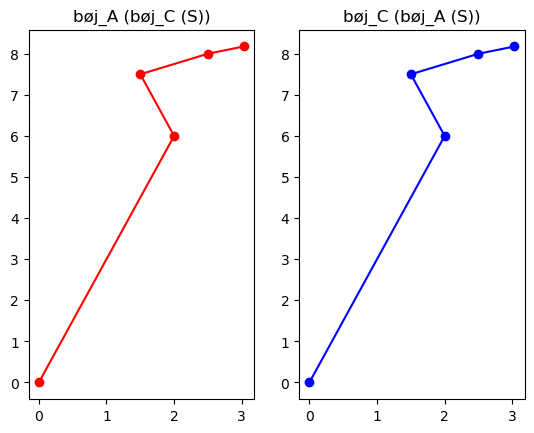

In [8]:
theta_A = np.pi/2
theta_C = np.pi/4

S_bend_A_C = bend(1, bend(3, S, theta_C), theta_A)
S_bend_C_A = bend(3, bend(1, S, theta_A), theta_C)

fig, ax = plt.subplots(1,2)
ax[0].plot(S_bend_A_C[:, 0], S_bend_A_C[:, 1], marker='o', color='red')
ax[0].set_title('bøj_A (bøj_C (S))')
ax[1].plot(S_bend_C_A[:, 0], S_bend_C_A[:, 1], marker='o', color='blue')
ax[1].set_title('bøj_C (bøj_A (S))')

In [9]:
S_bend_A_C == S_bend_C_A

array([[ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True]])